In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import tqdm
from pathlib import Path
import itertools

# ============================================================
# Parameters
# ============================================================


@dataclass
class Params:
    theta_L: float = 0.1
    theta_H: float = 0.9

    rho_minus: float = 0.20
    rho_plus: float = 0.80

    # User payoff parameters
    r: float = 1.0
    e: float = 0.50
    c: float = 0.20

    # Discount factor
    delta: float = 0.05

    eps: float = 1e-9


P = Params()

# Optional: uncomment one of these to force a knife-edge row in Table 1
# P.delta = 0.5
# P.delta = (1.0 - P.rho_minus) / (2.0 - P.rho_minus)   # activates Table 1 row 5
# P.delta = (1.0 - P.rho_plus) / (2.0 - P.rho_plus)     # activates Table 1 row 6

rho_star = 1.0 - (P.e - P.c) / P.r

assert 0 < P.theta_L < P.theta_H < 1
assert 0 < P.rho_minus < rho_star < P.rho_plus < 1
assert 0 < P.delta < 1


# ============================================================
# Basic functions
# ============================================================


def theta_bar(mu, P=P):
    return mu * P.theta_H + (1.0 - mu) * P.theta_L


def trust_threshold(P=P):
    return (rho_star - P.rho_minus) / (P.rho_plus - rho_star)


def trust_score(h, mu, P=P):
    A = theta_bar(mu, P)
    return (A / (1.0 - A)) * (1.0 / (1.0 - h))


def clip01(x, P=P):
    return min(max(x, P.eps), 1.0 - P.eps)


def in_tau_C(h, mu, P=P):
    if np.isnan(h) or np.isnan(mu):
        return False
    h = clip01(h, P)
    mu = clip01(mu, P)
    return trust_score(h, mu, P) >= trust_threshold(P) - P.eps


def in_tau_D(h, mu, P=P):
    if np.isnan(h) or np.isnan(mu):
        return False
    return not in_tau_C(h, mu, P)


def same_region(h1, mu1, h2, mu2, P=P):
    if any(np.isnan(x) for x in [h1, mu1, h2, mu2]):
        return False
    return (in_tau_C(h1, mu1, P) and in_tau_C(h2, mu2, P)) or (in_tau_D(h1, mu1, P) and in_tau_D(h2, mu2, P))


def user_ic_standard_delegation(u, P=P):
    return (u["rho_tilde_plus"] >= rho_star - P.eps) and (u["rho_tilde_minus"] <= rho_star + P.eps)


def user_ic_total_delegation(u, P=P):
    return (u["rho_tilde_plus"] >= rho_star - P.eps) and (u["rho_tilde_minus"] >= rho_star - P.eps)


def user_ic_total_rejection(u, P=P):
    return (u["rho_tilde_plus"] <= rho_star + P.eps) and (u["rho_tilde_minus"] <= rho_star + P.eps)


def user_ic_inverted_delegation(u, P=P):
    return (u["rho_tilde_plus"] <= rho_star + P.eps) and (u["rho_tilde_minus"] >= rho_star - P.eps)


def user_ic_partial_standard_delegation(u, P=P):
    return (abs(u["rho_tilde_plus"] - rho_star) <= P.eps) and (u["rho_tilde_minus"] <= rho_star + P.eps)


def user_ic_hedged_standard_delegation(u, P=P):
    return (u["rho_tilde_plus"] >= rho_star - P.eps) and (abs(u["rho_tilde_minus"] - rho_star) <= P.eps)


def user_ic_partial_inverted_delegation(u, P=P):
    return (u["rho_tilde_plus"] <= rho_star + P.eps) and (abs(u["rho_tilde_minus"] - rho_star) <= P.eps)


def user_ic_hedged_inverted_delegation(u, P=P):
    return (abs(u["rho_tilde_plus"] - rho_star) <= P.eps) and (u["rho_tilde_minus"] >= rho_star - P.eps)


# ============================================================
# Delta filter for Table 1
# ============================================================


def delta_ratio(P=P):
    return P.delta / (1.0 - P.delta)


def delta_condition_table1(row, P=P):
    R = delta_ratio(P)

    if row == 1:
        return True
    if row == 2:
        return P.delta > 0.5 - P.eps
    if row == 3:
        return abs(P.delta - 0.5) <= P.eps
    if row == 4:
        return R > (1.0 - P.rho_minus) - P.eps
    if row == 5:
        return abs(R - (1.0 - P.rho_minus)) <= P.eps
    if row == 6:
        return abs(R - (1.0 - P.rho_plus)) <= P.eps

    raise ValueError("Unknown Table 1 row")


def delta_condition_table4(row, P=P):
    R = delta_ratio(P)

    if row == 1:
        return abs(R - P.rho_minus) <= P.eps
    if row == 2:
        return abs(R - P.rho_plus) <= P.eps
    if row == 3:
        return abs(P.delta - 0.5) <= P.eps

    raise ValueError("Unknown Table 4 row")


def delta_condition_table5(row, P=P):
    R = delta_ratio(P)

    if row == 1:
        return True
    elif row == 2:
        return R >= 1 - P.rho_minus - P.eps
    elif row == 3:
        return R >= 1 - P.rho_minus - P.eps
    elif row == 4:
        return R >= 1 - P.eps

    raise ValueError("Unknown Table 5 row")


def delta_condition_table6(row, P=P):
    R = delta_ratio(P)

    if row == 1:
        return True
    elif row == 2:
        return R <= 1 - P.rho_plus + P.eps
    elif row == 3:
        return R >= P.rho_plus - P.eps
    elif row == 4:
        return True
    elif row == 5:
        return P.rho_plus < 0.5 + P.eps
    elif row == 6:
        return True
    elif row == 7:
        return R < 1 + P.eps
    elif row == 8:
        return True
    elif row == 9:
        return R < 1 + P.eps
    elif row == 10:
        return True
    elif row == 11:
        return True


def delta_condition_table7(row, P=P):
    R = delta_ratio(P)

    if row == 1:
        return (R >= 1 - P.rho_plus - P.eps) and (R <= 1 - P.rho_minus + P.eps)
    elif row == 2:
        return R >= 1 - P.rho_plus - P.eps
    elif row == 3:
        return R >= 1 - P.eps
    elif row == 4:
        return True


def delta_condition_table8(row, P=P):
    R = delta_ratio(P)

    if row == 1:
        return True
    elif row == 2:
        return R >= 1 - P.rho_plus - P.eps
    elif row == 3:
        return (R >= 1 - P.rho_plus - P.eps) and (R <= 1 - P.rho_minus + P.eps)


# ============================================================
# Reputation dynamics from Section C
# ============================================================


def reputation_updates(h, mu, sigma_plus, sigma_minus, P=P):
    A = theta_bar(mu, P)

    P_plus = h * A + (1.0 - h) * (A * sigma_plus + (1.0 - A) * sigma_minus)
    P_minus = 1.0 - P_plus

    out = {
        "P_plus": P_plus,
        "P_minus": P_minus,
    }

    # ---------- signal rho^+ ----------
    if P_plus <= P.eps:
        out.update(
            {
                "h_tilde_plus": np.nan,
                "mu_tilde_plus": np.nan,
                "theta_tilde_plus": np.nan,
                "rho_tilde_plus": np.nan,
                "h_success_plus": np.nan,
                "h_fail_plus": np.nan,
                "mu_success_plus": np.nan,
                "mu_fail_plus": np.nan,
            }
        )
    else:
        h_tilde_plus = h * A / P_plus

        mu_tilde_plus = (
            mu * (h * P.theta_H + (1.0 - h) * (P.theta_H * sigma_plus + (1.0 - P.theta_H) * sigma_minus)) / P_plus
        )

        theta_tilde_plus = A * (h + (1.0 - h) * sigma_plus) / P_plus

        rho_tilde_plus = theta_tilde_plus * P.rho_plus + (1.0 - theta_tilde_plus) * P.rho_minus

        h_success_plus = (P.rho_plus / rho_tilde_plus) * h_tilde_plus
        h_fail_plus = ((1.0 - P.rho_plus) / (1.0 - rho_tilde_plus)) * h_tilde_plus

        mu_success_plus = (
            mu
            * (
                h * P.theta_H * P.rho_plus
                + (1.0 - h) * (P.rho_plus * P.theta_H * sigma_plus + P.rho_minus * (1.0 - P.theta_H) * sigma_minus)
            )
            / (rho_tilde_plus * P_plus)
        )

        mu_fail_plus = (
            mu
            * (
                h * P.theta_H * (1.0 - P.rho_plus)
                + (1.0 - h)
                * ((1.0 - P.rho_plus) * P.theta_H * sigma_plus + (1.0 - P.rho_minus) * (1.0 - P.theta_H) * sigma_minus)
            )
            / ((1.0 - rho_tilde_plus) * P_plus)
        )

        out.update(
            {
                "h_tilde_plus": h_tilde_plus,
                "mu_tilde_plus": mu_tilde_plus,
                "theta_tilde_plus": theta_tilde_plus,
                "rho_tilde_plus": rho_tilde_plus,
                "h_success_plus": h_success_plus,
                "h_fail_plus": h_fail_plus,
                "mu_success_plus": mu_success_plus,
                "mu_fail_plus": mu_fail_plus,
            }
        )

    # ---------- signal rho^- ----------
    if P_minus <= P.eps:
        out.update(
            {
                "h_tilde_minus": np.nan,
                "mu_tilde_minus": np.nan,
                "theta_tilde_minus": np.nan,
                "rho_tilde_minus": np.nan,
                "h_success_minus": np.nan,
                "h_fail_minus": np.nan,
                "mu_success_minus": np.nan,
                "mu_fail_minus": np.nan,
            }
        )
    else:
        h_tilde_minus = h * (1.0 - A) / P_minus

        mu_tilde_minus = (
            mu
            * (
                h * (1.0 - P.theta_H)
                + (1.0 - h) * (P.theta_H * (1.0 - sigma_plus) + (1.0 - P.theta_H) * (1.0 - sigma_minus))
            )
            / P_minus
        )

        theta_tilde_minus = A * (1.0 - h) * (1.0 - sigma_plus) / P_minus

        rho_tilde_minus = theta_tilde_minus * P.rho_plus + (1.0 - theta_tilde_minus) * P.rho_minus

        h_success_minus = (P.rho_minus / rho_tilde_minus) * h_tilde_minus
        h_fail_minus = ((1.0 - P.rho_minus) / (1.0 - rho_tilde_minus)) * h_tilde_minus

        mu_success_minus = (
            mu
            * (
                h * (1.0 - P.theta_H) * P.rho_minus
                + (1.0 - h)
                * (P.rho_plus * P.theta_H * (1.0 - sigma_plus) + P.rho_minus * (1.0 - P.theta_H) * (1.0 - sigma_minus))
            )
            / (rho_tilde_minus * P_minus)
        )

        mu_fail_minus = (
            mu
            * (
                h * (1.0 - P.theta_H) * (1.0 - P.rho_minus)
                + (1.0 - h)
                * (
                    (1.0 - P.rho_plus) * P.theta_H * (1.0 - sigma_plus)
                    + (1.0 - P.rho_minus) * (1.0 - P.theta_H) * (1.0 - sigma_minus)
                )
            )
            / ((1.0 - rho_tilde_minus) * P_minus)
        )

        out.update(
            {
                "h_tilde_minus": h_tilde_minus,
                "mu_tilde_minus": mu_tilde_minus,
                "theta_tilde_minus": theta_tilde_minus,
                "rho_tilde_minus": rho_tilde_minus,
                "h_success_minus": h_success_minus,
                "h_fail_minus": h_fail_minus,
                "mu_success_minus": mu_success_minus,
                "mu_fail_minus": mu_fail_minus,
            }
        )

    return out


def cont_payoff(h, mu, P=P):
    return P.c if in_tau_C(h, mu, P) else 0


def cont_payoffs(u, P=P):
    payoffs = {
        "reject_pos": cont_payoff(u["h_tilde_plus"], u["mu_tilde_plus"], P),
        "reject_neg": cont_payoff(u["h_tilde_minus"], u["mu_tilde_minus"], P),
        "accept_pos": cont_payoff(u["h_accept_plus"], u["mu_accept_plus"], P),
        "accept_neg": cont_payoff(u["h_accept_minus"], u["mu_accept_minus"], P),
        "fail_pos": cont_payoff(u["h_fail_plus"], u["mu_fail_plus"], P),
        "fail_neg": cont_payoff(u["h_fail_minus"], u["mu_fail_minus"], P),
    }

    return payoffs


def agent_exp_payoff(u, s, rho, d_plus, d_minus, P=P):
    belief_updates = {}
    if s == P.rho_plus:
        belief_updates["h_interim"] = u["h_tilde_plus"]
        belief_updates["mu_interim"] = u["mu_tilde_plus"]
        belief_updates["h_success"] = u["h_success_plus"]
        belief_updates["mu_success"] = u["mu_success_plus"]
        belief_updates["h_fail"] = u["h_fail_plus"]
        belief_updates["mu_fail"] = u["mu_fail_plus"]
        del_prob = d_plus
    else:
        belief_updates["h_interim"] = u["h_tilde_minus"]
        belief_updates["mu_interim"] = u["mu_tilde_minus"]
        belief_updates["h_success"] = u["h_success_minus"]
        belief_updates["mu_success"] = u["mu_success_minus"]
        belief_updates["h_fail"] = u["h_fail_minus"]
        belief_updates["mu_fail"] = u["mu_fail_minus"]
        del_prob = d_minus

    success_continuation = cont_payoff(belief_updates["h_success"], belief_updates["mu_success"], P)
    failure_continuation = cont_payoff(belief_updates["h_fail"], belief_updates["mu_fail"], P)
    rejection_continuation = cont_payoff(belief_updates["h_interim"], belief_updates["mu_interim"], P)
    delegation_continuation = rho * success_continuation + (1 - rho) * failure_continuation
    return (
        del_prob * (P.delta * P.c + (1 - P.delta) * delegation_continuation)
        + (1 - del_prob) * (1 - P.delta) * rejection_continuation
    )

In [2]:
# ============================================================
# Table 1 conditions: Standard Delegation
# ============================================================


def cond_T1R1(h, mu, u, P=P):
    return (
        user_ic_standard_delegation(u, P) and in_tau_C(h, mu, P) and in_tau_C(u["h_fail_plus"], u["mu_fail_plus"], P)
    )


def cond_T1R2(h, mu, u, P=P):
    return (
        user_ic_standard_delegation(u, P)
        and in_tau_C(h, mu, P)
        and in_tau_D(u["h_success_plus"], u["mu_success_plus"], P)
    )


def cond_T1R3(h, mu, u, P=P):
    return (
        user_ic_standard_delegation(u, P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_D(u["h_success_plus"], u["mu_success_plus"], P)
    )


def cond_T1R4(h, mu, u, P=P):
    return (
        user_ic_standard_delegation(u, P)
        and in_tau_C(h, mu, P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
    )


def cond_T1R5(h, mu, u, P=P):
    return (
        user_ic_standard_delegation(u, P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
    )


def cond_T1R6(h, mu, u, P=P):
    # same as displayed in the previous screenshot
    return (
        user_ic_standard_delegation(u, P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
    )


# ============================================================
# Table 2 conditions: Total Delegation
# ============================================================


def cond_T2R1(h, mu, u, P=P):
    # exact visible conditions + user IC for total delegation
    return (
        user_ic_total_delegation(u, P)
        and same_region(
            u["h_success_plus"],
            u["mu_success_plus"],
            u["h_fail_plus"],
            u["mu_fail_plus"],
            P,
        )
        and same_region(
            u["h_success_minus"],
            u["mu_success_minus"],
            u["h_fail_minus"],
            u["mu_fail_minus"],
            P,
        )
    )


# ============================================================
# Table 3 conditions: Total Rejection
# ============================================================


def cond_T3R1(h, mu, u, P=P):
    return (
        user_ic_total_rejection(u, P)
        and in_tau_D(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_D(u["h_tilde_plus"], u["mu_tilde_plus"], P)
    )


def cond_T3R2(h, mu, u, P=P):
    return (
        user_ic_total_rejection(u, P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
    )


# ============================================================
# Table 4 conditions: Inverted Delegation
# ============================================================


def cond_T4R1(h, mu, u, P=P):
    return (
        user_ic_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
    )


def cond_T4R2(h, mu, u, P=P):
    return (
        user_ic_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
    )


def cond_T4R3(h, mu, u, P=P):
    return (
        user_ic_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_D(u["h_fail_minus"], u["mu_fail_minus"], P)
    )


# ============================================================
# Table 5 conditions: Partial Standard Delegation
# ============================================================


def cond_T5R1(h, mu, u, P=P):
    return (
        user_ic_partial_standard_delegation(u, P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_C(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
    )


def cond_T5R2(h, mu, u, P=P):
    return (
        user_ic_partial_standard_delegation(u, P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
    )


def cond_T5R3(h, mu, u, P=P):
    return (
        user_ic_partial_standard_delegation(u, P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_D(u["h_tilde_plus"], u["mu_tilde_plus"], P)
    )


def cond_T5R4(h, mu, u, P=P):
    return (
        user_ic_partial_standard_delegation(u, P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_D(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_D(u["h_tilde_plus"], u["mu_tilde_plus"], P)
    )


# ============================================================
# Table 6 conditions: Hedged Standard Delegation
# ============================================================


def cond_T6R1(h, mu, u, P=P):
    return (
        user_ic_hedged_standard_delegation(u, P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_C(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T6R2(h, mu, u, P=P):
    return (
        user_ic_hedged_standard_delegation(u, P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_C(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_D(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T6R3(h, mu, u, P=P):
    return (
        user_ic_hedged_standard_delegation(u, P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_C(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_D(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T6R4(h, mu, u, P=P):
    return (
        user_ic_hedged_standard_delegation(u, P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T6R5(h, mu, u, P=P):
    return (
        user_ic_hedged_standard_delegation(u, P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_D(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T6R6(h, mu, u, P=P):
    return (
        user_ic_hedged_standard_delegation(u, P)
        and in_tau_D(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_C(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T6R7(h, mu, u, P=P):
    return (
        user_ic_hedged_standard_delegation(u, P)
        and in_tau_D(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_C(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_D(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T6R8(h, mu, u, P=P):
    return (
        user_ic_hedged_standard_delegation(u, P)
        and in_tau_D(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_C(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_D(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T6R9(h, mu, u, P=P):
    return (
        user_ic_hedged_standard_delegation(u, P)
        and in_tau_D(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T6R10(h, mu, u, P=P):
    return (
        user_ic_hedged_standard_delegation(u, P)
        and in_tau_D(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_C(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_D(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_D(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T6R11(h, mu, u, P=P):
    return (
        user_ic_hedged_standard_delegation(u, P)
        and in_tau_D(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_D(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


# ============================================================
# Table 7 conditions: Partial Inverted Delegation
# ============================================================


def cond_T7R1(h, mu, u, P=P):
    return (
        user_ic_partial_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_C(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_D(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T7R2(h, mu, u, P=P):
    return (
        user_ic_partial_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_D(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T7R3(h, mu, u, P=P):
    return (
        user_ic_partial_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_D(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_D(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )


def cond_T7R4(h, mu, u, P=P):
    return (
        user_ic_partial_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
    )

    # ============================================================


# Table 8 conditions: Hedged Inverted Delegation
# ============================================================


def cond_T8R1(h, mu, u, P=P):
    return (
        user_ic_hedged_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_C(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_D(u["h_fail_minus"], u["mu_fail_minus"], P)
    )


def cond_T8R2(h, mu, u, P=P):
    return (
        user_ic_hedged_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_C(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_C(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_D(u["h_fail_minus"], u["mu_fail_minus"], P)
    )


def cond_T8R3(h, mu, u, P=P):
    return (
        user_ic_hedged_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
        and in_tau_C(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_D(u["h_fail_minus"], u["mu_fail_minus"], P)
    )

In [ ]:
# ============================================================
# Strategy samplers
# ============================================================


def user_sampler_table1_row(row, n=50, P=P):
    # Table 1
    return [(1.0, 0.0, "d(+)=1, d(-)=0")]


def agent_sampler_table1_row(row, h, mu, d_plus, d_minus, n=10, P=P):
    # Table 1
    if row in [1, 2, 4]:
        return [(1.0, 1.0, "sigma(+)=1, sigma(-)=1")]

    if row == 3:
        # row 3 appears to be sigma(.) in [0,1], i.e. same value for both
        grid = np.linspace(0.0, 1.0, n)
        return [(s, s, f"sigma(+)=sigma(-)={s:.3f}") for s in grid]

    if row == 5:
        # sigma(+)=1, sigma(-) in (0,1]
        grid_minus = np.linspace(0.0, 1.0, n + 1)[1:]
        return [(1.0, sm, f"sigma(+)=1, sigma(-)={sm:.3f}") for sm in grid_minus]

    if row == 6:
        # sigma(+) in [0,1), sigma(-) in (0,1]
        grid_plus = np.linspace(0.0, 1.0, n + 1)[:-1]
        grid_minus = np.linspace(0.0, 1.0, n + 1)[1:]
        return [(sp, sm, f"sigma(+)={sp:.3f}, sigma(-)={sm:.3f}") for sp in grid_plus for sm in grid_minus]

    raise ValueError("Unknown Table 1 row")


def user_sampler_table2_row(row, n=50, P=P):
    # Table 2
    return [(1.0, 1.0, "d(+)=1, d(-)=1")]


def agent_sampler_table2_row(row, h, mu, d_plus, d_minus, n=10, P=P):
    # Table 2 row 1*: sigma(+) in [0,1], sigma(-) in [0,1]
    grid = np.linspace(0.0, 1.0, n)
    return [(sp, sm, f"sigma(+)={sp:.3f}, sigma(-)={sm:.3f}") for sp in grid for sm in grid]


def user_sampler_table3_row(row, n=50, P=P):
    # Table 3
    return [(0.0, 0.0, "d(+)=0, d(-)=0")]


def agent_sampler_table3_row(row, h, mu, d_plus, d_minus, n=10, P=P):
    # Table 3 rows: sigma(+) in [0,1], sigma(-) in (0,1]
    grid_plus = np.linspace(0.0, 1.0, n)
    grid_minus = np.linspace(0.0, 1.0, n + 1)[1:]
    return [(sp, sm, f"sigma(+)={sp:.3f}, sigma(-)={sm:.3f}") for sp in grid_plus for sm in grid_minus]


def user_sampler_table4_row(row, n=50, P=P):
    # Table 4
    return [(0.0, 1.0, "d(+)=0, d(-)=1")]


def agent_sampler_table4_row(row, h, mu, d_plus, d_minus, n=10, P=P):
    # Table 4 rows:
    grid_plus = np.linspace(0.0, 1.0, n + 1)[:-1]
    grid_minus = np.linspace(0.0, 1.0, n + 1)[1:]
    strict_mix = np.linspace(0.0, 1.0, n + 2)[1:-1]

    if row == 1:
        return [(0, sm, f"sigma(+)=0, sigma(-)={sm:.3f}") for sm in strict_mix]

    if row == 2:
        return [(sp, 1, f"sigma(+)={sp:.3f}, sigma(-)=1") for sp in strict_mix]

    if row == 3:
        return [(sp, sm, f"sigma(+)={sp:.3f}, sigma(-)={sm:.3f}") for sp in grid_plus for sm in grid_minus]


def user_sampler_table5_row(row, n=10, P=P):
    # Table 5 rows:

    if row == 1:
        user_plus = np.linspace(0.0, 1.0, n + 2)[1:-1]
        return [(up, 0, f"d(+)={up:.3f}, d(-)=0") for up in user_plus]

    if row == 2:
        user_plus = np.linspace(0.0, 1.0, n + 2)[1:-1]
        return [(up, 0, f"d(+)={up:.3f}, d(-)=0") for up in user_plus]

    if row == 3:
        user_threshold = (1 - P.rho_minus) / delta_ratio(P)
        user_plus = np.linspace(user_threshold, 1.0, n + 1)[:-1]
        return [(up, 0, f"d(+)={up:.3f}, d(-)=0") for up in user_plus]

    if row == 4:
        user_threshold = 1 / delta_ratio(P)
        user_plus = np.linspace(user_threshold, 1.0, n + 1)[:-1]
        return [(up, 0, f"d(+)={up:.3f}, d(-)=0") for up in user_plus]

    raise ValueError("Unknown Table 5 row")


def agent_sampler_table5_row(row, h, mu, d_plus, d_minus, n=10, P=P):
    # Table 5 rows:
    agent_minus = np.linspace(0.0, 1.0, n + 1)[1:]

    if row == 1:
        return [(1, 1, "sigma(+)=1, sigma(-)=1")]

    if row == 2:
        if delta_ratio(P) > (1.0 - P.rho_minus) - P.eps:
            return [(1, 1, "sigma(+)=1, sigma(-)=1")]
        elif abs(delta_ratio(P) - (1.0 - P.rho_minus)) <= P.eps:
            agent_minus_mix = min(
                1,
                max(
                    0,
                    (theta_bar(mu, P) / (1 - theta_bar(mu, P))) / ((1 - h) * trust_threshold(P)),
                ),
            )
            return [(1, agent_minus_mix, f"sigma(+)=0, sigma(-)={agent_minus_mix:.3f}")]

    if row == 3:
        if delta_ratio(P) * d_plus > (1.0 - P.rho_minus) - P.eps:
            return [(1, 1, "sigma(+)=1, sigma(-)=1")]
        elif abs(delta_ratio(P) * d_plus - (1.0 - P.rho_minus)) <= P.eps:
            agent_minus_mix = min(
                1,
                max(
                    0,
                    (theta_bar(mu, P) / (1 - theta_bar(mu, P))) / ((1 - h) * trust_threshold(P)),
                ),
            )
            return [(1, agent_minus_mix, f"sigma(+)=0, sigma(-)={agent_minus_mix:.3f}")]

    if row == 4:
        if delta_ratio(P) * d_plus > 1 - P.eps:
            return [(1, 1, "sigma(+)=1, sigma(-)=1")]
        elif abs(delta_ratio(P) * d_plus - 1) <= P.eps:
            agent_plus = np.linspace(0.0, 1.0, n)
            agent_minus = np.linspace(0.0, 1.0, n + 1)[1:]
            return [(ap, am, f"sigma(+)={ap:.3f}, sigma(-)={am:.3f}") for ap in agent_plus for am in agent_minus]

    raise ValueError("Unknown Table 5 row")


def user_sampler_table6_row(row, n=10, P=P):
    # Table 6 rows:
    user_minus = np.linspace(0, 1, n + 2)[1:-1]

    if row == 1:
        user_min_mix = max(0, 1 - ((1 - P.rho_plus) / delta_ratio(P)))
        user_minus = np.linspace(user_min_mix, 1.0, n + 1)[:-1]
        return [(1, um, f"d(+)=1, d(-)={um:.3f}") for um in user_minus]
    elif row == 2:
        return [(1, um, f"d(+)=1, d(-)={um:.3f}") for um in user_minus]
    elif row == 3:
        user_min_mix = P.delta + (1 - P.delta) * P.rho_plus
        user_minus = np.linspace(user_min_mix, 1.0, n + 1)[:-1]
        return [(1, um, f"d(+)=1, d(-)={um:.3f}") for um in user_minus]
    elif row == 4:
        user_max_mix = min(
            1,
            max(
                0,
                ((1 - P.delta) * (1 - P.rho_plus) - P.delta) / (P.rho_plus * (1 - P.delta) - P.delta),
            ),
        )
        user_minus = np.linspace(0, user_max_mix, n + 1)[1:]
        return [(1, um, f"d(+)=1, d(-)={um:.3f}") for um in user_minus]
    elif row == 5:
        user_min_mix = min(
            1,
            (P.delta + (1 - P.delta) * P.rho_plus) / (P.delta + (1 - P.delta) * (1 - P.rho_plus)),
        )
        return [(1, um, f"d(+)=1, d(-)={um:.3f}") for um in user_minus]
    elif row == 6:
        user_min_mix = min(1, max(0, (2 * P.delta - 1) / P.delta))
        user_minus = np.linspace(user_min_mix, 1.0, n + 1)[:-1]
        return [(1, um, f"d(+)=1, d(-)={um:.3f}") for um in user_minus]
    elif row == 7:
        user_min_mix = min(
            1,
            max(0, (2 * P.delta - 1) / (2 * P.delta - 1 + (1 - P.delta) * P.rho_plus)),
        )
        user_minus = np.linspace(user_min_mix, 1.0, n + 1)[:-1]
        return [(1, um, f"d(+)=1, d(-)={um:.3f}") for um in user_minus]
    elif row == 8:
        user_min_mix = P.delta
        user_minus = np.linspace(user_min_mix, 1.0, n + 1)[:-1]
        return [(1, um, f"d(+)=1, d(-)={um:.3f}") for um in user_minus]
    elif row == 9:
        user_min_mix = min(1, max(0, (2 * P.delta - 1) / (P.delta - (1 - P.delta) * P.rho_plus)))
        user_minus = np.linspace(user_min_mix, 1.0, n + 1)[:-1]
        return [(1, um, f"d(+)=1, d(-)={um:.3f}") for um in user_minus]
    elif row == 10:
        user_min_mix = min(1, max(0, P.delta / (P.delta + (1 - P.delta) * P.rho_plus)))
        user_minus = np.linspace(user_min_mix, 1.0, n + 1)[:-1]
        return [(1, um, f"d(+)=1, d(-)={um:.3f}") for um in user_minus]
    elif row == 11:
        user_min_mix = min(1, max(0, P.delta / (P.delta + (1 - P.delta) * (1 - P.rho_plus))))
        user_minus = np.linspace(user_min_mix, 1.0, n + 1)[:-1]
        return [(1, um, f"d(+)=1, d(-)={um:.3f}") for um in user_minus]

    raise ValueError("Unknown Table 6 row")


def agent_sampler_table6_row(row, h, mu, d_plus, d_minus, n=10, P=P):
    # Table 6 rows:
    A = theta_bar(mu, P) / (1 - theta_bar(mu, P))
    agent_minus = np.linspace(0, 1, n + 1)[1:]

    if row == 1:
        agent_plus_mix = min(1, max(0, 1 - (trust_threshold(P) / (A * (1 - h)))))
        return [(agent_plus_mix, 0, f"sigma(+)={agent_plus_mix:.3f}, sigma(-)=0")]
    elif row == 2:
        agent_plus_mix = min(1, max(0, 1 - (trust_threshold(P) / (A * (1 - h)))))
        return [(agent_plus_mix, 0, f"sigma(+)={agent_plus_mix:.3f}, sigma(-)=0")]
    elif row == 3:
        agent_plus_mix = min(1, max(0, 1 - (trust_threshold(P) / (A * (1 - h)))))
        return [(agent_plus_mix, 0, f"sigma(+)={agent_plus_mix:.3f}, sigma(-)=0")]
    elif row == 4:
        agent_plus_mix = min(1, max(0, 1 - (trust_threshold(P) / (A * (1 - h)))))
        return [(agent_plus_mix, 0, f"sigma(+)={agent_plus_mix:.3f}, sigma(-)=0")]
    elif row == 5:
        agent_plus_mix = min(1, max(0, 1 - (trust_threshold(P) / (A * (1 - h)))))
        return [(agent_plus_mix, 0, f"sigma(+)={agent_plus_mix:.3f}, sigma(-)=0")]
    elif row == 6:
        agent_plus_mix = np.clip(
            1 - ((trust_threshold(P) * (h + (1 - h) * (1 - agent_minus))) / (A * (1 - h))),
            0,
            1,
        )
        return [(ap, am, f"sigma(+)={ap:.3f}, sigma(-)={am:.3f}") for ap, am in zip(agent_plus_mix, agent_minus)]
    elif row == 7:
        agent_plus_mix = np.clip(
            1 - ((trust_threshold(P) * (h + (1 - h) * (1 - agent_minus))) / (A * (1 - h))),
            0,
            1,
        )
        return [(ap, am, f"sigma(+)={ap:.3f}, sigma(-)={am:.3f}") for ap, am in zip(agent_plus_mix, agent_minus)]
    elif row == 8:
        agent_plus_mix = np.clip(
            1 - ((trust_threshold(P) * (h + (1 - h) * (1 - agent_minus))) / (A * (1 - h))),
            0,
            1,
        )
        return [(ap, am, f"sigma(+)={ap:.3f}, sigma(-)={am:.3f}") for ap, am in zip(agent_plus_mix, agent_minus)]
    elif row == 9:
        agent_plus_mix = min(1, max(0, 1 - (trust_threshold(P) / (A * (1 - h)))))
        return [(agent_plus_mix, 0, f"sigma(+)={agent_plus_mix:.3f}, sigma(-)=0")]
    elif row == 10:
        agent_plus_mix = np.clip(
            1 - ((trust_threshold(P) * (h + (1 - h) * (1 - agent_minus))) / (A * (1 - h))),
            0,
            1,
        )
        return [(ap, am, f"sigma(+)={ap:.3f}, sigma(-)={am:.3f}") for ap, am in zip(agent_plus_mix, agent_minus)]
    elif row == 11:
        agent_plus_mix = min(1, max(0, 1 - (trust_threshold(P) / (A * (1 - h)))))
        return [(agent_plus_mix, 0, f"sigma(+)={agent_plus_mix:.3f}, sigma(-)=0")]

    raise ValueError("Unknown Table 6 row")


def user_sampler_table7_row(row, n=10, P=P):
    # Table 7 rows:

    if row == 1:
        user_minus = np.linspace(0.0, 1.0, n + 2)[1:-1]
        return [(0, um, f"d(+)=0, d(-)={um:.3f}") for um in user_minus]

    if row == 2:
        user_min_mix = min(1, max(0, (1 - P.delta) / (P.delta + P.rho_plus * (1 - P.delta))))
        user_max_mix = max(0, min(1, (1 - P.delta) / (P.delta + P.rho_minus * (1 - P.delta))))
        user_minus = np.linspace(user_min_mix, user_max_mix, n)
        return [(0, um, f"d(+)=0, d(-)={um:.3f}") for um in user_minus]

    if row == 3:
        user_minus = 1 / delta_ratio(P)
        return [(0, user_minus, f"d(+)=0, d(-)={user_minus:.3f}")]

    if row == 4:
        user_minus = 1 - P.delta
        return [(0, user_minus, f"d(+)=0, d(-)={user_minus:.3f}")]

    raise ValueError("Unknown Table 7 row")


def agent_sampler_table7_row(row, h, mu, d_plus, d_minus, n=10, P=P):
    # Table 7 rows:
    A = theta_bar(mu, P) / (1 - theta_bar(mu, P))
    if row == 1:
        if abs(delta_ratio(P) - (1 - P.rho_plus)) < P.eps:
            agent_plus_mix = min(1, max(0, 1 - (h * trust_threshold(P)) / ((1 - h) * A)))
            return [(agent_plus_mix, 1, f"sigma(+)={agent_plus_mix:.3f}, sigma(-)=1")]
        elif abs(delta_ratio(P) - (1 - P.rho_minus)) < P.eps:
            agent_minus_mix = min(1, max(0, 1 - ((A * (1 - h) / trust_threshold(P)) - h) / (1 - h)))
            return [(0, agent_minus_mix, f"sigma(+)=0, sigma(-)={agent_minus_mix:.3f}")]
        else:
            return [(0, 1, "sigma(+)=0, sigma(-)=1")]
    elif row == 2:
        if abs(delta_ratio(P) - ((1 - P.rho_plus * d_minus) / d_minus)) < P.eps:
            agent_plus_mix = min(1, max(0, 1 - (h * trust_threshold(P)) / ((1 - h) * A)))
            return [(agent_plus_mix, 1, f"sigma(+)={agent_plus_mix:.3f}, sigma(-)=1")]
        elif abs(delta_ratio(P) - ((1 - P.rho_minus * d_minus) / d_minus)) < P.eps:
            agent_minus_mix = (
                0,
                min(1, max(0, 1 - ((A * (1 - h) / trust_threshold(P)) - h) / (1 - h))),
            )
            return [(0, agent_minus_mix, f"sigma(+)=0, sigma(-)={agent_minus_mix:.3f}")]
        else:
            return [(0, 1, "sigma(+)=0, sigma(-)=1")]
    elif row == 3:
        agent_minus = np.linspace(0.0, 1.0, n + 1)[1:]
        agent_plus_mix = np.clip(
            1 - (trust_threshold(P) * (h + (1 - h) * (1 - agent_minus))) / ((1 - h) * A),
            0,
            1,
        )
        return [(ap, am, f"sigma(+)={ap:.3f}, sigma(-)={am:.3f}") for ap, am in zip(agent_plus_mix, agent_minus)]
    elif row == 4:
        agent_minus = np.linspace(0.0, 1.0, n + 1)[1:]
        agent_plus_mix = np.clip(
            1 - (trust_threshold(P) * (h + (1 - h) * (1 - agent_minus))) / ((1 - h) * A),
            0,
            1,
        )
        return [(ap, am, f"sigma(+)={ap:.3f}, sigma(-)={am:.3f}") for ap, am in zip(agent_plus_mix, agent_minus)]


def user_sampler_table8_row(row, n=10, P=P):
    # Table 8 rows:

    if row == 1:
        user_plus_mix = (2 * P.delta - 1) / P.delta
        return [(user_plus_mix, 1, f"d(+)={user_plus_mix:.3f}, d(-)=1")]

    if row == 2:
        user_min_mix = min(1, max(0, 1 - ((1 - P.rho_minus) / delta_ratio(P))))
        user_max_mix = max(0, min(1, 1 - ((1 - P.rho_plus) / delta_ratio(P))))
        user_plus = np.linspace(user_min_mix, user_max_mix, n)
        return [(up, 1, f"d(+)={up:.3f}, d(-)=1") for up in user_plus]

    if row == 3:
        user_plus = np.linspace(0.0, 1.0, n + 2)[1:-1]
        return [(up, 1, f"d(+)={up:.3f}, d(-)=1") for up in user_plus]

    raise ValueError("Unknown Table 8 row")


def agent_sampler_table8_row(row, h, mu, d_plus, d_minus, n=10, P=P):
    # Table 8 rows:
    A = theta_bar(mu, P) / (1 - theta_bar(mu, P))

    if row == 1:
        agent_minus = np.linspace(0.0, 1.0, n + 1)[1:]
        agent_plus_mix = np.clip((((trust_threshold(P) * (1 - h) * agent_minus) / A) - h) / (1 - h), 0, 1)
        return [(ap, am, f"sigma(+)={ap:.3f}, sigma(-)={am:.3f}") for ap, am in zip(agent_plus_mix, agent_minus)]
    elif row == 2:
        if abs(delta_ratio(P) * (1 - d_plus) - (1 - P.rho_plus)) < P.eps:
            agent_plus_mix = min(1, max(0, (((trust_threshold(P) * (1 - h)) / A) - h) / (1 - h)))
            return [(agent_plus_mix, 1, f"sigma(+)={agent_plus_mix:.3f}, sigma(-)=1")]
        elif abs(delta_ratio(P) * (1 - d_plus) - (1 - P.rho_minus)) < P.eps:
            agent_minus_mix = min(1, max(0, A * h / (trust_threshold(P) * (1 - h))))
            return [(0, agent_minus_mix, f"sigma(+)=0, sigma(-)={agent_minus_mix:.3f}")]
        else:
            return [(0, 1, "sigma(+)=0, sigma(-)=1")]
    elif row == 3:
        if abs(delta_ratio(P) - (1 - P.rho_plus)) < P.eps:
            agent_plus_mix = min(1, max(0, (((trust_threshold(P) * (1 - h)) / A) - h) / (1 - h)))
            return [(agent_plus_mix, 1, f"sigma(+)={agent_plus_mix:.3f}, sigma(-)=1")]
        elif abs(delta_ratio(P) - (1 - P.rho_minus)) < P.eps:
            agent_minus_mix = min(1, max(0, A * h / (trust_threshold(P) * (1 - h))))
            return [(0, agent_minus_mix, f"sigma(+)=0, sigma(-)={agent_minus_mix:.3f}")]
        else:
            return [(0, 1, "sigma(+)=0, sigma(-)=1")]


# ============================================================
# Row specs
# ============================================================

ROW_SPECS = [
    # Table 1
    {
        "key": "T1R1",
        "table": "Table 1: Standard Delegation",
        "row": 1,
        "condition": cond_T1R1,
        "user_sampler": user_sampler_table1_row,
        "agent_sampler": agent_sampler_table1_row,
        "active": lambda P=P: delta_condition_table1(1, P),
        "color": "tab:blue",
    },
    {
        "key": "T1R2",
        "table": "Table 1: Standard Delegation",
        "row": 2,
        "condition": cond_T1R2,
        "user_sampler": user_sampler_table1_row,
        "agent_sampler": agent_sampler_table1_row,
        "active": lambda P=P: delta_condition_table1(2, P),
        "color": "tab:orange",
    },
    {
        "key": "T1R3",
        "table": "Table 1: Standard Delegation",
        "row": 3,
        "condition": cond_T1R3,
        "user_sampler": user_sampler_table1_row,
        "agent_sampler": agent_sampler_table1_row,
        "active": lambda P=P: delta_condition_table1(3, P),
        "color": "tab:green",
    },
    {
        "key": "T1R4",
        "table": "Table 1: Standard Delegation",
        "row": 4,
        "condition": cond_T1R4,
        "user_sampler": user_sampler_table1_row,
        "agent_sampler": agent_sampler_table1_row,
        "active": lambda P=P: delta_condition_table1(4, P),
        "color": "tab:red",
    },
    {
        "key": "T1R5",
        "table": "Table 1: Standard Delegation",
        "row": 5,
        "condition": cond_T1R5,
        "user_sampler": user_sampler_table1_row,
        "agent_sampler": agent_sampler_table1_row,
        "active": lambda P=P: delta_condition_table1(5, P),
        "color": "tab:purple",
    },
    {
        "key": "T1R6",
        "table": "Table 1: Standard Delegation",
        "row": 6,
        "condition": cond_T1R6,
        "user_sampler": user_sampler_table1_row,
        "agent_sampler": agent_sampler_table1_row,
        "active": lambda P=P: delta_condition_table1(6, P),
        "color": "tab:brown",
    },
    # Table 2
    {
        "key": "T2R1",
        "table": "Table 2: Total Delegation",
        "row": 1,
        "condition": cond_T2R1,
        "user_sampler": user_sampler_table2_row,
        "agent_sampler": agent_sampler_table2_row,
        "active": lambda P=P: True,
        "color": "tab:blue",
    },
    # Table 3
    {
        "key": "T3R1",
        "table": "Table 3: Total Rejection",
        "row": 1,
        "condition": cond_T3R1,
        "user_sampler": user_sampler_table3_row,
        "agent_sampler": agent_sampler_table3_row,
        "active": lambda P=P: True,
        "color": "tab:blue",
    },
    {
        "key": "T3R2",
        "table": "Table 3: Total Rejection",
        "row": 2,
        "condition": cond_T3R2,
        "user_sampler": user_sampler_table3_row,
        "agent_sampler": agent_sampler_table3_row,
        "active": lambda P=P: True,
        "color": "tab:orange",
    },
    # Table 4
    {
        "key": "T4R1",
        "table": "Table 4: Inverted Delegation",
        "row": 1,
        "condition": cond_T4R1,
        "user_sampler": user_sampler_table4_row,
        "agent_sampler": agent_sampler_table4_row,
        "active": lambda P=P: delta_condition_table4(1, P),
        "color": "tab:blue",
    },
    {
        "key": "T4R2",
        "table": "Table 4: Inverted Delegation",
        "row": 2,
        "condition": cond_T4R2,
        "user_sampler": user_sampler_table4_row,
        "agent_sampler": agent_sampler_table4_row,
        "active": lambda P=P: delta_condition_table4(2, P),
        "color": "tab:orange",
    },
    {
        "key": "T4R3",
        "table": "Table 4: Inverted Delegation",
        "row": 3,
        "condition": cond_T4R3,
        "user_sampler": user_sampler_table4_row,
        "agent_sampler": agent_sampler_table4_row,
        "active": lambda P=P: delta_condition_table4(3, P),
        "color": "tab:green",
    },
    # Table 5
    {
        "key": "T5R1",
        "table": "Table 5: Partial Standard",
        "row": 1,
        "condition": cond_T5R1,
        "user_sampler": user_sampler_table5_row,
        "agent_sampler": agent_sampler_table5_row,
        "active": lambda P=P: delta_condition_table5(1, P),
        "color": "tab:blue",
    },
    {
        "key": "T5R2",
        "table": "Table 5: Partial Standard",
        "row": 2,
        "condition": cond_T5R2,
        "user_sampler": user_sampler_table5_row,
        "agent_sampler": agent_sampler_table5_row,
        "active": lambda P=P: delta_condition_table5(2, P),
        "color": "tab:orange",
    },
    {
        "key": "T5R3",
        "table": "Table 5: Partial Standard",
        "row": 3,
        "condition": cond_T5R3,
        "user_sampler": user_sampler_table5_row,
        "agent_sampler": agent_sampler_table5_row,
        "active": lambda P=P: delta_condition_table5(3, P),
        "color": "tab:green",
    },
    {
        "key": "T5R4",
        "table": "Table 5: Partial Standard",
        "row": 4,
        "condition": cond_T5R4,
        "user_sampler": user_sampler_table5_row,
        "agent_sampler": agent_sampler_table5_row,
        "active": lambda P=P: delta_condition_table5(4, P),
        "color": "tab:red",
    },
    # Table 6
    {
        "key": "T6R1",
        "table": "Table 6: Hedged Standard",
        "row": 1,
        "condition": cond_T6R1,
        "user_sampler": user_sampler_table6_row,
        "agent_sampler": agent_sampler_table6_row,
        "active": lambda P=P: delta_condition_table6(1, P),
        "color": "tab:blue",
    },
    {
        "key": "T6R2",
        "table": "Table 6: Hedged Standard",
        "row": 2,
        "condition": cond_T6R2,
        "user_sampler": user_sampler_table6_row,
        "agent_sampler": agent_sampler_table6_row,
        "active": lambda P=P: delta_condition_table6(2, P),
        "color": "tab:orange",
    },
    {
        "key": "T6R3",
        "table": "Table 6: Hedged Standard",
        "row": 3,
        "condition": cond_T6R3,
        "user_sampler": user_sampler_table6_row,
        "agent_sampler": agent_sampler_table6_row,
        "active": lambda P=P: delta_condition_table6(3, P),
        "color": "tab:green",
    },
    {
        "key": "T6R4",
        "table": "Table 6: Hedged Standard",
        "row": 4,
        "condition": cond_T6R4,
        "user_sampler": user_sampler_table6_row,
        "agent_sampler": agent_sampler_table6_row,
        "active": lambda P=P: delta_condition_table6(4, P),
        "color": "tab:red",
    },
    {
        "key": "T6R5",
        "table": "Table 6: Hedged Standard",
        "row": 5,
        "condition": cond_T6R5,
        "user_sampler": user_sampler_table6_row,
        "agent_sampler": agent_sampler_table6_row,
        "active": lambda P=P: delta_condition_table6(5, P),
        "color": "tab:purple",
    },
    {
        "key": "T6R6",
        "table": "Table 6: Hedged Standard",
        "row": 6,
        "condition": cond_T6R6,
        "user_sampler": user_sampler_table6_row,
        "agent_sampler": agent_sampler_table6_row,
        "active": lambda P=P: delta_condition_table6(6, P),
        "color": "tab:brown",
    },
    {
        "key": "T6R7",
        "table": "Table 6: Hedged Standard",
        "row": 7,
        "condition": cond_T6R7,
        "user_sampler": user_sampler_table6_row,
        "agent_sampler": agent_sampler_table6_row,
        "active": lambda P=P: delta_condition_table6(7, P),
        "color": "tab:pink",
    },
    {
        "key": "T6R8",
        "table": "Table 6: Hedged Standard",
        "row": 8,
        "condition": cond_T6R8,
        "user_sampler": user_sampler_table6_row,
        "agent_sampler": agent_sampler_table6_row,
        "active": lambda P=P: delta_condition_table6(8, P),
        "color": "tab:gray",
    },
    {
        "key": "T6R9",
        "table": "Table 6: Hedged Standard",
        "row": 9,
        "condition": cond_T6R9,
        "user_sampler": user_sampler_table6_row,
        "agent_sampler": agent_sampler_table6_row,
        "active": lambda P=P: delta_condition_table6(9, P),
        "color": "tab:olive",
    },
    {
        "key": "T6R10",
        "table": "Table 6: Hedged Standard",
        "row": 10,
        "condition": cond_T6R10,
        "user_sampler": user_sampler_table6_row,
        "agent_sampler": agent_sampler_table6_row,
        "active": lambda P=P: delta_condition_table6(10, P),
        "color": "tab:cyan",
    },
    {
        "key": "T6R11",
        "table": "Table 6: Hedged Standard",
        "row": 11,
        "condition": cond_T6R11,
        "user_sampler": user_sampler_table6_row,
        "agent_sampler": agent_sampler_table6_row,
        "active": lambda P=P: delta_condition_table6(11, P),
        "color": "black",
    },
    # Table 7
    {
        "key": "T7R1",
        "table": "Table 7: Partial Inverted",
        "row": 1,
        "condition": cond_T7R1,
        "user_sampler": user_sampler_table7_row,
        "agent_sampler": agent_sampler_table7_row,
        "active": lambda P=P: delta_condition_table7(1, P),
        "color": "tab:blue",
    },
    {
        "key": "T7R2",
        "table": "Table 7: Partial Inverted",
        "row": 2,
        "condition": cond_T7R2,
        "user_sampler": user_sampler_table7_row,
        "agent_sampler": agent_sampler_table7_row,
        "active": lambda P=P: delta_condition_table7(2, P),
        "color": "tab:orange",
    },
    {
        "key": "T7R3",
        "table": "Table 7: Partial Inverted",
        "row": 3,
        "condition": cond_T7R3,
        "user_sampler": user_sampler_table7_row,
        "agent_sampler": agent_sampler_table7_row,
        "active": lambda P=P: delta_condition_table7(3, P),
        "color": "tab:green",
    },
    {
        "key": "T7R4",
        "table": "Table 7: Partial Inverted",
        "row": 4,
        "condition": cond_T7R4,
        "user_sampler": user_sampler_table7_row,
        "agent_sampler": agent_sampler_table7_row,
        "active": lambda P=P: delta_condition_table7(4, P),
        "color": "tab:red",
    },
    # Table 8
    {
        "key": "T8R1",
        "table": "Table 8: Hedged Inverted",
        "row": 1,
        "condition": cond_T8R1,
        "user_sampler": user_sampler_table8_row,
        "agent_sampler": agent_sampler_table8_row,
        "active": lambda P=P: delta_condition_table8(1, P),
        "color": "tab:blue",
    },
    {
        "key": "T8R2",
        "table": "Table 8: Hedged Inverted",
        "row": 2,
        "condition": cond_T8R2,
        "user_sampler": user_sampler_table8_row,
        "agent_sampler": agent_sampler_table8_row,
        "active": lambda P=P: delta_condition_table8(2, P),
        "color": "tab:orange",
    },
    {
        "key": "T8R3",
        "table": "Table 8: Hedged Inverted",
        "row": 3,
        "condition": cond_T8R3,
        "user_sampler": user_sampler_table8_row,
        "agent_sampler": agent_sampler_table8_row,
        "active": lambda P=P: delta_condition_table8(3, P),
        "color": "tab:green",
    },
]

In [4]:
# ============================================================
# Scan Function Encapsulation
# ============================================================


def run_and_save_scan(P: Params, n_grid=99, n_mixed_samples=10, max_failures_to_save=4000000, verbose=True):
    rho_star = 1.0 - (P.e - P.c) / P.r
    h_values = np.linspace(0.01, 0.99, n_grid)
    mu_values = np.linspace(0.01, 0.99, n_grid)

    active_specs = [spec for spec in ROW_SPECS if spec["active"](P)]

    success_points = {spec["key"]: [] for spec in active_specs}
    failures = []
    summary = []

    if verbose:
        print("========================================")
        print("Parameters")
        print("========================================")
        print(P)
        print(f"rho_star = {rho_star:.6f}")
        print(f"delta/(1-delta) = {delta_ratio(P):.6f}")
        print(f"tau threshold = {trust_threshold(P):.6f}")
        print("Active rows:")
        for spec in active_specs:
            print(f"  {spec['key']}: {spec['table']}, row {spec['row']}")
        print("========================================\n")

    for spec in tqdm.tqdm(active_specs, desc="Specs", position=0, leave=True, disable=not verbose):
        key = spec["key"]
        cond = spec["condition"]
        strategy_samples = spec["sampler"](spec["row"], n_mixed_samples)

        count_success = 0

        grid_search = list(itertools.product(h_values, mu_values))

        for h, mu in tqdm.tqdm(
            grid_search,
            desc=f"Scanning {key}",
            position=1,
            leave=True,
            disable=not verbose,
        ):
            for sigma_plus, sigma_minus, strategy_label in strategy_samples:
                u = reputation_updates(h, mu, sigma_plus, sigma_minus, P)

                ok = cond(h, mu, u, P)

                if ok:
                    success_points[key].append((h, mu, sigma_plus, sigma_minus))
                    count_success += 1
                else:
                    if max_failures_to_save is None or len(failures) < max_failures_to_save:
                        failures.append(
                            {
                                "key": key,
                                "table": spec["table"],
                                "row": spec["row"],
                                "h1": h,
                                "mu1": mu,
                                "sigma_plus": sigma_plus,
                                "sigma_minus": sigma_minus,
                                "strategy": strategy_label,
                                "delta": P.delta,
                                "delta_ratio": delta_ratio(P),
                                "rho_star": rho_star,
                                "tau_threshold": trust_threshold(P),
                                "P_plus": u.get("P_plus", np.nan),
                                "P_minus": u.get("P_minus", np.nan),
                                "h_tilde_plus": u.get("h_tilde_plus", np.nan),
                                "mu_tilde_plus": u.get("mu_tilde_plus", np.nan),
                                "rho_tilde_plus": u.get("rho_tilde_plus", np.nan),
                                "h_tilde_minus": u.get("h_tilde_minus", np.nan),
                                "mu_tilde_minus": u.get("mu_tilde_minus", np.nan),
                                "rho_tilde_minus": u.get("rho_tilde_minus", np.nan),
                                "h_success_plus": u.get("h_success_plus", np.nan),
                                "mu_success_plus": u.get("mu_success_plus", np.nan),
                                "h_fail_plus": u.get("h_fail_plus", np.nan),
                                "mu_fail_plus": u.get("mu_fail_plus", np.nan),
                                "h_success_minus": u.get("h_success_minus", np.nan),
                                "mu_success_minus": u.get("mu_success_minus", np.nan),
                                "h_fail_minus": u.get("h_fail_minus", np.nan),
                                "mu_fail_minus": u.get("mu_fail_minus", np.nan),
                                "in_tauC_h_mu": in_tau_C(h, mu, P),
                                "in_tauC_tilde_plus": in_tau_C(
                                    u.get("h_tilde_plus", np.nan),
                                    u.get("mu_tilde_plus", np.nan),
                                    P,
                                ),
                                "in_tauC_tilde_minus": in_tau_C(
                                    u.get("h_tilde_minus", np.nan),
                                    u.get("mu_tilde_minus", np.nan),
                                    P,
                                ),
                                "in_tauC_success_plus": in_tau_C(
                                    u.get("h_success_plus", np.nan),
                                    u.get("mu_success_plus", np.nan),
                                    P,
                                ),
                                "in_tauC_fail_plus": in_tau_C(
                                    u.get("h_fail_plus", np.nan),
                                    u.get("mu_fail_plus", np.nan),
                                    P,
                                ),
                                "in_tauC_success_minus": in_tau_C(
                                    u.get("h_success_minus", np.nan),
                                    u.get("mu_success_minus", np.nan),
                                    P,
                                ),
                                "in_tauC_fail_minus": in_tau_C(
                                    u.get("h_fail_minus", np.nan),
                                    u.get("mu_fail_minus", np.nan),
                                    P,
                                ),
                                "user_ic_total_delegate": user_ic_total_delegation(u, P),
                                "user_ic_total_reject": user_ic_total_rejection(u, P),
                            }
                        )

        summary.append(
            {
                "key": key,
                "table": spec["table"],
                "row": spec["row"],
                "color": spec["color"],
                "num_satisfying_points": count_success,
            }
        )

    summary_df = pd.DataFrame(summary)

    # Save parameter values alongside the results
    param_dict = {
        "theta_L": P.theta_L,
        "theta_H": P.theta_H,
        "rho_minus": P.rho_minus,
        "rho_plus": P.rho_plus,
        "r": P.r,
        "e": P.e,
        "c": P.c,
        "delta": P.delta,
        "eps": P.eps,
        "rho_star": rho_star,
        "delta_ratio": delta_ratio(P),
        "tau_threshold": trust_threshold(P),
    }

    RELATIVE_SUBPATH = Path("outputs/numericals")
    SAVE_DIR = Path.cwd().parent.parent.parent / RELATIVE_SUBPATH
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

    SAVE_DIR.joinpath("equilibrium_tables").mkdir(parents=True, exist_ok=True)
    SAVE_DIR.joinpath("equilibrium_plots").mkdir(parents=True, exist_ok=True)

    table_path = SAVE_DIR / f"equilibrium_tables/summary_{timestamp}.csv"
    params_path = SAVE_DIR / f"equilibrium_tables/params_{timestamp}.csv"
    plot_path = SAVE_DIR / f"equilibrium_plots/equilibrium_regions_{timestamp}.png"

    summary_df.to_csv(table_path, index=False)
    pd.DataFrame([param_dict]).to_csv(params_path, index=False)

    if verbose:
        print(summary_df)
        print()
        print(f"Saved {table_path.name} with {len(summary_df)} rows")
        print(f"Saved {params_path.name} with parameter config")

    table_names = [
        "Table 1: Standard Delegation",
        "Table 2: Total Delegation",
        "Table 3: Total Rejection",
        "Table 4: Inverted Delegation",
    ]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)

    param_str = f"$\\theta_L={P.theta_L}, \\theta_H={P.theta_H}, \\rho^-={P.rho_minus}, \\rho^+={P.rho_plus}, c={P.c}, e={P.e}, r={P.r}, \\delta={P.delta}$"
    fig.suptitle(f"Equilibrium Regions — Params: {param_str}", fontsize=14, y=1.05)

    for ax, table_name in zip(axes, table_names):
        for spec in active_specs:
            if spec["table"] != table_name:
                continue

            pts = np.array(success_points[spec["key"]])
            if len(pts) == 0:
                continue

            ax.scatter(
                pts[:, 0],
                pts[:, 1],
                s=8,
                alpha=0.45,
                color=spec["color"],
                label=f"{spec['key']}",
            )

        h_grid = np.linspace(0.01, 0.99, 99)
        T = trust_threshold(P)
        A_boundary = T * (1.0 - h_grid) / (1.0 + T * (1.0 - h_grid))
        mu_boundary = (A_boundary - P.theta_L) / (P.theta_H - P.theta_L)
        mask = (mu_boundary >= 0.0) & (mu_boundary <= 1.0)

        ax.plot(
            h_grid[mask],
            mu_boundary[mask],
            color="black",
            linewidth=2,
            label=r"$\tau_C/\tau_D$ boundary",
        )

        ax.set_title(table_name)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="best")

    axes[0].set_ylabel(r"$\mu_1$")
    for ax in axes:
        ax.set_xlabel(r"$h_1$")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")

    if verbose:
        plt.show()
        print(f"Saved {plot_path.name} with equilibrium region plots")
    else:
        plt.close()

In [10]:
# ============================================================
# Scan Function Encapsulation
# ============================================================


def run_and_save_scan_user_mix(P: Params, n_grid=99, n_mixed_samples=10, max_failures_to_save=4000000, verbose=True):
    rho_star = 1.0 - (P.e - P.c) / P.r
    h_values = np.linspace(0.01, 0.99, n_grid)
    mu_values = np.linspace(0.01, 0.99, n_grid)

    active_specs = [spec for spec in ROW_SPECS if spec["active"](P)]

    success_points = {spec["key"]: [] for spec in active_specs}
    failures = []
    summary = []

    if verbose:
        print("========================================")
        print("Parameters")
        print("========================================")
        print(P)
        print(f"rho_star = {rho_star:.6f}")
        print(f"delta/(1-delta) = {delta_ratio(P):.6f}")
        print(f"tau threshold = {trust_threshold(P):.6f}")
        print("Active rows:")
        for spec in active_specs:
            print(f"  {spec['key']}: {spec['table']}, row {spec['row']}")
        print("========================================\n")

    for spec in tqdm.tqdm(active_specs, desc="Specs", position=0, leave=True, disable=not verbose):
        key = spec["key"]
        cond = spec["condition"]
        user_strategy_samples = spec["user_sampler"](spec["row"], n_mixed_samples, P)

        count_success = 0

        grid_search = list(itertools.product(h_values, mu_values))

        for h, mu in tqdm.tqdm(
            grid_search,
            desc=f"Scanning {key}",
            position=1,
            leave=True,
            disable=not verbose,
        ):
            for d_plus, d_minus, strategy_label in user_strategy_samples:
                agent_strategy_samples = spec["agent_sampler"](spec["row"], h, mu, d_plus, d_minus, n_mixed_samples, P)
                for sigma_plus, sigma_minus, strategy_label in agent_strategy_samples:
                    u = reputation_updates(h, mu, sigma_plus, sigma_minus, P)

                    ok = cond(h, mu, u, P)

                    if ok:
                        success_points[key].append((h, mu, d_plus, d_minus, sigma_plus, sigma_minus))
                        count_success += 1
                    else:
                        if max_failures_to_save is None or len(failures) < max_failures_to_save:
                            failures.append(
                                {
                                    "key": key,
                                    "table": spec["table"],
                                    "row": spec["row"],
                                    "h1": h,
                                    "mu1": mu,
                                    "d_plus": d_plus,
                                    "d_minus": d_minus,
                                    "sigma_plus": sigma_plus,
                                    "sigma_minus": sigma_minus,
                                    "strategy": strategy_label,
                                    "delta": P.delta,
                                    "delta_ratio": delta_ratio(P),
                                    "rho_star": rho_star,
                                    "tau_threshold": trust_threshold(P),
                                    "P_plus": u.get("P_plus", np.nan),
                                    "P_minus": u.get("P_minus", np.nan),
                                    "h_tilde_plus": u.get("h_tilde_plus", np.nan),
                                    "mu_tilde_plus": u.get("mu_tilde_plus", np.nan),
                                    "rho_tilde_plus": u.get("rho_tilde_plus", np.nan),
                                    "h_tilde_minus": u.get("h_tilde_minus", np.nan),
                                    "mu_tilde_minus": u.get("mu_tilde_minus", np.nan),
                                    "rho_tilde_minus": u.get("rho_tilde_minus", np.nan),
                                    "h_success_plus": u.get("h_success_plus", np.nan),
                                    "mu_success_plus": u.get("mu_success_plus", np.nan),
                                    "h_fail_plus": u.get("h_fail_plus", np.nan),
                                    "mu_fail_plus": u.get("mu_fail_plus", np.nan),
                                    "h_success_minus": u.get("h_success_minus", np.nan),
                                    "mu_success_minus": u.get("mu_success_minus", np.nan),
                                    "h_fail_minus": u.get("h_fail_minus", np.nan),
                                    "mu_fail_minus": u.get("mu_fail_minus", np.nan),
                                    "in_tauC_h_mu": in_tau_C(h, mu, P),
                                    "in_tauC_tilde_plus": in_tau_C(
                                        u.get("h_tilde_plus", np.nan),
                                        u.get("mu_tilde_plus", np.nan),
                                        P,
                                    ),
                                    "in_tauC_tilde_minus": in_tau_C(
                                        u.get("h_tilde_minus", np.nan),
                                        u.get("mu_tilde_minus", np.nan),
                                        P,
                                    ),
                                    "in_tauC_success_plus": in_tau_C(
                                        u.get("h_success_plus", np.nan),
                                        u.get("mu_success_plus", np.nan),
                                        P,
                                    ),
                                    "in_tauC_fail_plus": in_tau_C(
                                        u.get("h_fail_plus", np.nan),
                                        u.get("mu_fail_plus", np.nan),
                                        P,
                                    ),
                                    "in_tauC_success_minus": in_tau_C(
                                        u.get("h_success_minus", np.nan),
                                        u.get("mu_success_minus", np.nan),
                                        P,
                                    ),
                                    "in_tauC_fail_minus": in_tau_C(
                                        u.get("h_fail_minus", np.nan),
                                        u.get("mu_fail_minus", np.nan),
                                        P,
                                    ),
                                    "user_ic_total_delegate": user_ic_total_delegation(u, P),
                                    "user_ic_total_reject": user_ic_total_rejection(u, P),
                                }
                            )

        summary.append(
            {
                "key": key,
                "table": spec["table"],
                "row": spec["row"],
                "color": spec["color"],
                "num_satisfying_points": count_success,
            }
        )

    summary_df = pd.DataFrame(summary)

    # Save parameter values alongside the results
    param_dict = {
        "theta_L": P.theta_L,
        "theta_H": P.theta_H,
        "rho_minus": P.rho_minus,
        "rho_plus": P.rho_plus,
        "r": P.r,
        "e": P.e,
        "c": P.c,
        "delta": P.delta,
        "eps": P.eps,
        "rho_star": rho_star,
        "delta_ratio": delta_ratio(P),
        "tau_threshold": trust_threshold(P),
    }

    RELATIVE_SUBPATH = Path("outputs/numericals")
    SAVE_DIR = Path.cwd().parent.parent.parent / RELATIVE_SUBPATH
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

    SAVE_DIR.joinpath("equilibrium_tables").mkdir(parents=True, exist_ok=True)
    SAVE_DIR.joinpath("equilibrium_plots").mkdir(parents=True, exist_ok=True)

    table_path = SAVE_DIR / f"equilibrium_tables/summary_{timestamp}.csv"
    params_path = SAVE_DIR / f"equilibrium_tables/params_{timestamp}.csv"
    plot_path = SAVE_DIR / f"equilibrium_plots/equilibrium_regions_{timestamp}.png"
    # success_pts_path = SAVE_DIR / f"equilibrium_tables/success_points_{timestamp}.json"

    summary_df.to_csv(table_path, index=False)
    pd.DataFrame([param_dict]).to_csv(params_path, index=False)
    # with open(success_pts_path, "w") as f:
    #     json.dump(success_points, f)

    if verbose:
        print(summary_df)
        print()
        print(f"Saved {table_path.name} with {len(summary_df)} rows")
        print(f"Saved {params_path.name} with parameter config")

    table_names = [
        "Table 1: Standard Delegation",
        "Table 2: Total Delegation",
        "Table 3: Total Rejection",
        "Table 4: Inverted Delegation",
        "Table 5: Partial Standard",
        "Table 6: Hedged Standard",
        "Table 7: Partial Inverted",
        "Table 8: Hedged Inverted",
    ]

    fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
    axes = axes.flatten()
    param_str = f"$\\theta_L={P.theta_L}, \\theta_H={P.theta_H}, \\rho^-={P.rho_minus}, \\rho^+={P.rho_plus}, c={P.c}, e={P.e}, r={P.r}, \\delta={P.delta}$"
    fig.suptitle(f"Equilibrium Regions — Params: {param_str}", fontsize=14, y=1.05)

    for ax, table_name in zip(axes, table_names):
        for spec in active_specs:
            if spec["table"] != table_name:
                continue

            pts = np.array(success_points[spec["key"]])
            if len(pts) == 0:
                continue

            ax.scatter(
                pts[:, 0],
                pts[:, 1],
                s=8,
                alpha=0.45,
                color=spec["color"],
                label=f"{spec['key']}",
            )

        h_grid = np.linspace(0.01, 0.99, 99)
        T = trust_threshold(P)
        A_boundary = T * (1.0 - h_grid) / (1.0 + T * (1.0 - h_grid))
        mu_boundary = (A_boundary - P.theta_L) / (P.theta_H - P.theta_L)
        mask = (mu_boundary >= 0.0) & (mu_boundary <= 1.0)

        ax.plot(
            h_grid[mask],
            mu_boundary[mask],
            color="black",
            linewidth=2,
            label=r"$\tau_C/\tau_D$ boundary",
        )

        ax.set_title(table_name)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="best")

    axes[0].set_ylabel(r"$\mu_1$")
    axes[4].set_ylabel(r"$\mu_1$")
    for ax in axes:
        ax.set_xlabel(r"$h_1$")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=500, bbox_inches="tight")

    if verbose:
        plt.show()
        print(f"Saved {plot_path.name} with equilibrium region plots")
    else:
        plt.close()

    return summary_df, success_points

Parameter Grid Search:   0%|          | 0/1 [00:00<?, ?it/s]

Parameters
Params(theta_L=0.4, theta_H=0.9, rho_minus=0.2, rho_plus=0.8, r=1.0, e=0.5, c=0.2, delta=0.25, eps=0.01)
rho_star = 0.700000
delta/(1-delta) = 0.333333
tau threshold = 5.000000
Active rows:
  T1R1: Table 1: Standard Delegation, row 1
  T2R1: Table 2: Total Delegation, row 1
  T3R1: Table 3: Total Rejection, row 1
  T3R2: Table 3: Total Rejection, row 2
  T5R1: Table 5: Partial Standard, row 1
  T6R1: Table 6: Hedged Standard, row 1
  T6R4: Table 6: Hedged Standard, row 4
  T6R6: Table 6: Hedged Standard, row 6
  T6R7: Table 6: Hedged Standard, row 7
  T6R8: Table 6: Hedged Standard, row 8
  T6R9: Table 6: Hedged Standard, row 9
  T6R10: Table 6: Hedged Standard, row 10
  T6R11: Table 6: Hedged Standard, row 11
  T7R1: Table 7: Partial Inverted, row 1
  T7R2: Table 7: Partial Inverted, row 2
  T7R4: Table 7: Partial Inverted, row 4
  T8R1: Table 8: Hedged Inverted, row 1
  T8R2: Table 8: Hedged Inverted, row 2
  T8R3: Table 8: Hedged Inverted, row 3



Specs: 100%|██████████| 19/19 [17:09<00:00, 54.20s/it]


      key                         table  row       color  \
0    T1R1  Table 1: Standard Delegation    1    tab:blue   
1    T2R1     Table 2: Total Delegation    1    tab:blue   
2    T3R1      Table 3: Total Rejection    1    tab:blue   
3    T3R2      Table 3: Total Rejection    2  tab:orange   
4    T5R1     Table 5: Partial Standard    1    tab:blue   
5    T6R1      Table 6: Hedged Standard    1    tab:blue   
6    T6R4      Table 6: Hedged Standard    4     tab:red   
7    T6R6      Table 6: Hedged Standard    6   tab:brown   
8    T6R7      Table 6: Hedged Standard    7    tab:pink   
9    T6R8      Table 6: Hedged Standard    8    tab:gray   
10   T6R9      Table 6: Hedged Standard    9   tab:olive   
11  T6R10      Table 6: Hedged Standard   10    tab:cyan   
12  T6R11      Table 6: Hedged Standard   11       black   
13   T7R1     Table 7: Partial Inverted    1    tab:blue   
14   T7R2     Table 7: Partial Inverted    2  tab:orange   
15   T7R4     Table 7: Partial Inverted 

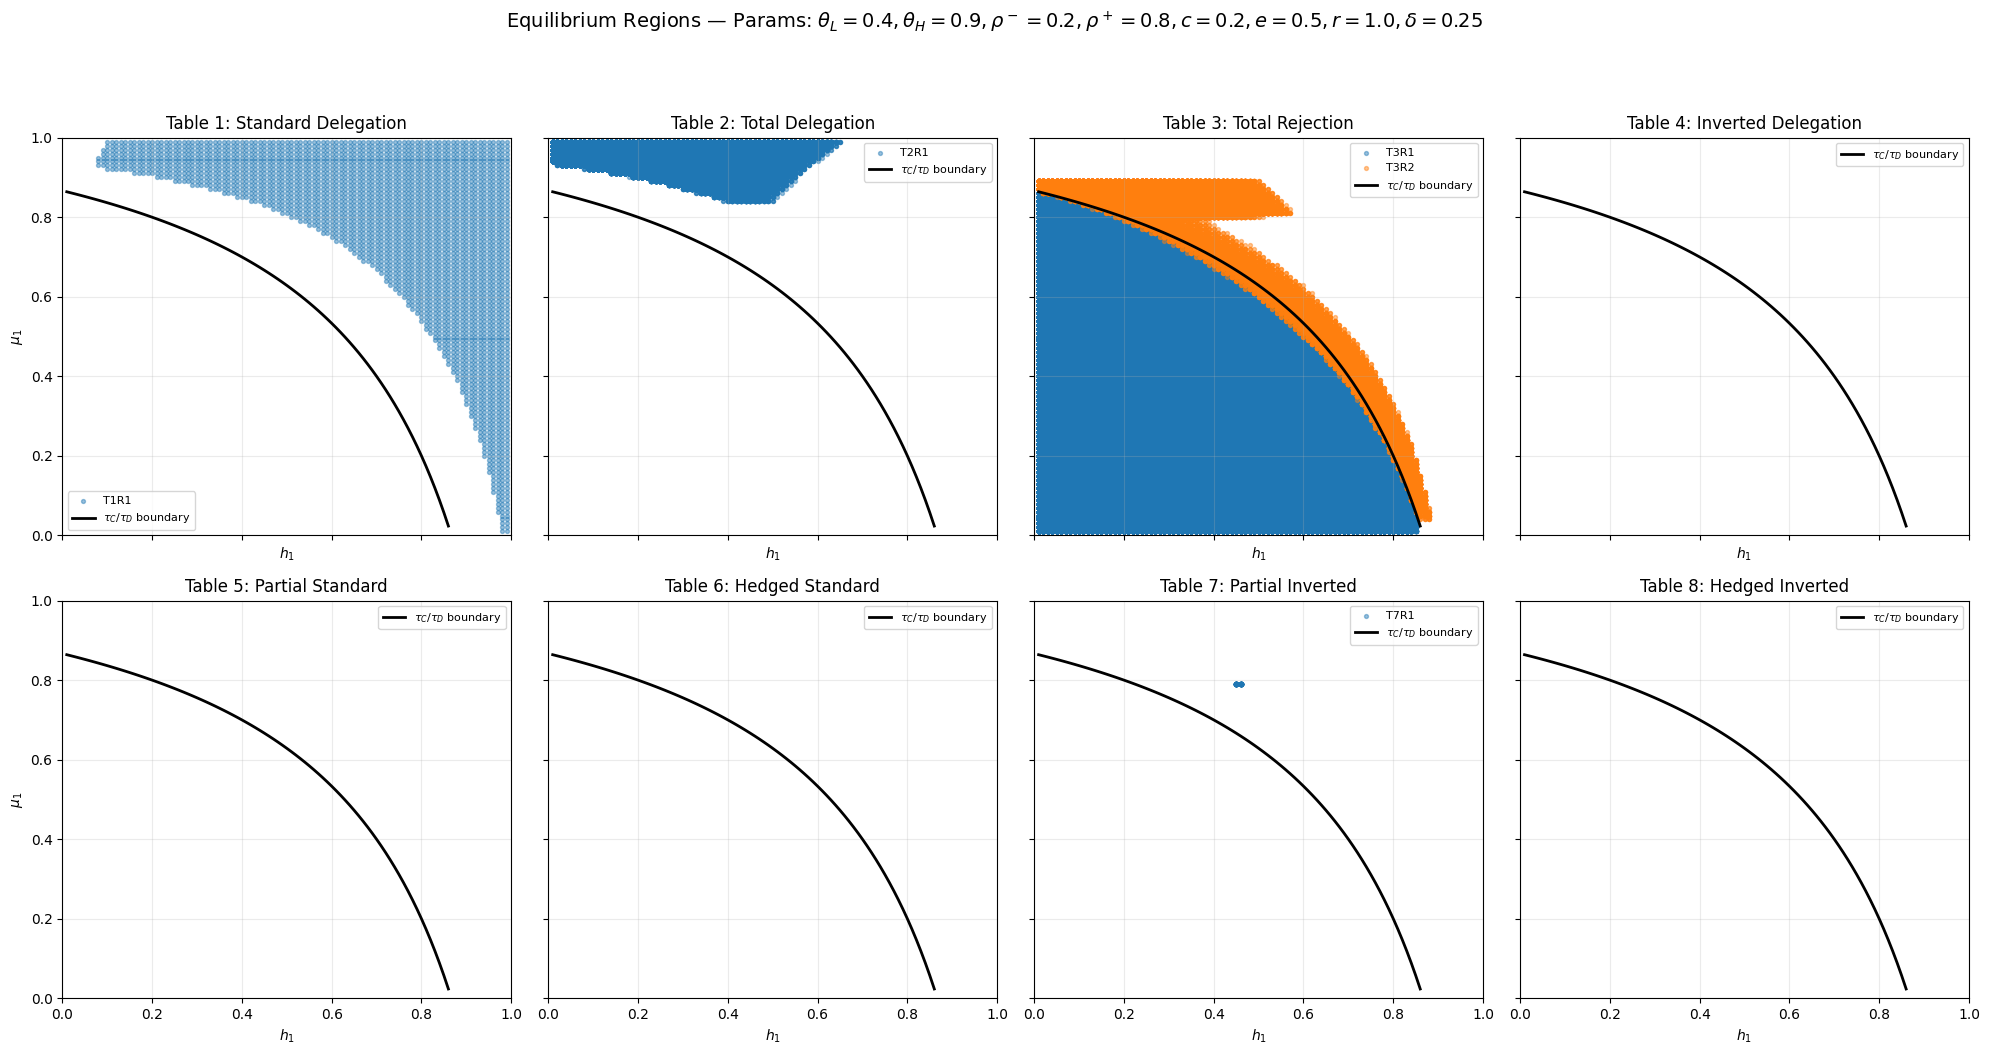

Parameter Grid Search: 100%|██████████| 1/1 [17:48<00:00, 1068.18s/it]

Saved equilibrium_regions_20260604_232309.png with equilibrium region plots


In [ ]:
# ============================================================
# Loop Run
# ============================================================
delta_vals = [0.25]  # [0.05, 0.1666666, 0.25, 0.44444444, 0.5, 0.95] # [0.25] # [0.5] # [0.8] #
theta_L_vals = [0.4]  # [0.1, 0.4] #, 0.2, 0.3, 0.4] #[0.1, 0.4]#, 0.2, 0.3, 0.4] #[0.4] # [0.01] # [0.1] #
theta_H_vals = [0.9]  # [0.8, 0.83, 0.9] # [0.9] # [0.99] # [0.9] # [0.9, 0.83]#, 0.7, 0.8, 0.9] #
rho_minus_vals = [0.2]  # , 0.2, 0.3, 0.4]
rho_plus_vals = [0.8]  # , 0.7, 0.8, 0.9]

param_combinations = list(itertools.product(delta_vals, theta_L_vals, theta_H_vals, rho_minus_vals, rho_plus_vals))

for delta_val, theta_L_val, theta_H_val, rho_minus_val, rho_plus_val in tqdm.tqdm(
    param_combinations, desc="Parameter Grid Search"
):
    P = Params(
        delta=delta_val,
        theta_L=theta_L_val,
        theta_H=theta_H_val,
        rho_minus=rho_minus_val,
        rho_plus=rho_plus_val,
        eps=1e-2,
    )
    rho_star = 1.0 - (P.e - P.c) / P.r

    if not (0 < P.rho_minus < rho_star < P.rho_plus < 1):
        continue

    # Using leave=False inside run_and_save_scan and verbose=False avoids cluttering the terminal
    # and prevents print statements/figures from disrupting the outer progress bar.
    summary_df, success_points = run_and_save_scan_user_mix(P, n_mixed_samples=25, verbose=True)

In [15]:
success_points

{'T1R1': [(np.float64(0.08), np.float64(0.93), 1.0, 0.0, 1.0, 1.0),
  (np.float64(0.08), np.float64(0.9400000000000001), 1.0, 0.0, 1.0, 1.0),
  (np.float64(0.08), np.float64(0.9500000000000001), 1.0, 0.0, 1.0, 1.0),
  (np.float64(0.09), np.float64(0.93), 1.0, 0.0, 1.0, 1.0),
  (np.float64(0.09), np.float64(0.9400000000000001), 1.0, 0.0, 1.0, 1.0),
  (np.float64(0.09), np.float64(0.9500000000000001), 1.0, 0.0, 1.0, 1.0),
  (np.float64(0.09), np.float64(0.9600000000000001), 1.0, 0.0, 1.0, 1.0),
  (np.float64(0.09), np.float64(0.97), 1.0, 0.0, 1.0, 1.0),
  (np.float64(0.09999999999999999), np.float64(0.92), 1.0, 0.0, 1.0, 1.0),
  (np.float64(0.09999999999999999), np.float64(0.93), 1.0, 0.0, 1.0, 1.0),
  (np.float64(0.09999999999999999),
   np.float64(0.9400000000000001),
   1.0,
   0.0,
   1.0,
   1.0),
  (np.float64(0.09999999999999999),
   np.float64(0.9500000000000001),
   1.0,
   0.0,
   1.0,
   1.0),
  (np.float64(0.09999999999999999),
   np.float64(0.9600000000000001),
   1.0,
   0.